# My First FNO

Now, let's try learning Fresnel propagation using a Fourier Neural Operator!

In [20]:
import torch
import torch.nn as nn
import os
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt

Define FNO components

In [21]:
def activation(name):
    if name in ['tanh', 'Tanh']:
        return nn.Tanh()
    elif name in ['relu', 'ReLU']:
        return nn.ReLU(inplace=True)
    elif name in ['lrelu', 'LReLU']:
        return nn.LeakyReLU(inplace=True)
    elif name in ['sigmoid', 'Sigmoid']:
        return nn.Sigmoid()
    elif name in ['softplus', 'Softplus']:
        return nn.Softplus(beta=4)
    elif name in ['celu', 'CeLU']:
        return nn.CELU()
    elif name in ['elu']:
        return nn.ELU()
    elif name in ['mish']:
        return nn.Mish()
    else:
        raise ValueError('Unknown activation function')
    

Define Fourier Layers in 2D

In [22]:
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super(SpectralConv2d, self).__init__()

        """
        2D Fourier layer. It does FFT, linear transform, and Inverse FFT.
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1  # Number of Fourier modes to multiply, at most floor(N/2) + 1
        self.modes2 = modes2

        self.scale = (1 / (in_channels * out_channels))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))

    # Complex multiplication
    
    def compl_mul2d(self, input, weights):
        # (batch, in_channel, x,y ), (in_channel, out_channel, x,y) -> (batch, out_channel, x,y)
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        # Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.fft.rfft2(x)

        # Multiply relevant Fourier modes
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-2), x.size(-1) // 2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2] = \
            self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = \
            self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)

        # Return to physical space
        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return x

Define overall architecture in 2D

In [23]:
class FNO2d(nn.Module):
    def __init__(self, fno_architecture, device=None, padding_frac=1 / 4):
        super(FNO2d, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .

        input: the solution of the coefficient function and locations (a(x, y), x, y)
        input shape: (batchsize, x=s, y=s, c=3)
        output: the solution
        output shape: (batchsize, x=s, y=s, c=2)  -- Re and Im of propagated field
        """
        self.modes1 = fno_architecture["modes1"]
        self.modes2 = fno_architecture["modes2"]
        self.width = fno_architecture["width"]
        self.n_layers = fno_architecture["n_layers"]
        self.retrain_fno = fno_architecture["retrain_fno"]

        torch.manual_seed(self.retrain_fno)
        # self.padding = 9 # pad the domain if input is non-periodic
        self.padding_frac = padding_frac
        self.fc0 = nn.Linear(3, self.width)  # input channel is 3: (z, Re(field), Im(field))

        self.conv_list = nn.ModuleList(
            [nn.Conv2d(self.width, self.width, 1) for _ in range(self.n_layers)])
        self.spectral_list = nn.ModuleList(
            [SpectralConv2d(self.width, self.width, self.modes1, self.modes2) for _ in range(self.n_layers)])

        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, 2)  # 2 output channels: Re and Im of propagated field

        self.to(device)

    def forward(self, x):
        x = self.fc0(x)
        x = x.permute(0, 3, 1, 2)

        x1_padding = int(round(x.shape[-1] * self.padding_frac))
        x2_padding = int(round(x.shape[-2] * self.padding_frac))
        x = F.pad(x, [0, x1_padding, 0, x2_padding])

        for k, (s, c) in enumerate(zip(self.spectral_list, self.conv_list)):

            x1 = s(x)
            x2 = c(x)
            x = x1 + x2
            if k != self.n_layers - 1:
                x = F.gelu(x)
        x = x[..., :-x1_padding, :-x2_padding]

        x = x.permute(0, 2, 3, 1)
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.fc2(x)
        return x  # shape: (batch, H, W, 2)


# Learning Fresnel Propagation

Start by loading the data.

In [24]:
torch.manual_seed(0)
np.random.seed(0)

n_train = 900
# number of training samples
# The remaining set of samples constitute the testing dataset

# Load data
# Format for each sample is (n_samples, 3, N, N): (propagation distance, Re(input field), Im(input field))

x_data = torch.from_numpy(np.load("fresnel_dataset\inputs.npy"))

# Format for each sample is (n_samples, 2, N, N): (Re(output field), Im(output field))

y_data = torch.from_numpy(np.load("fresnel_dataset\outputs.npy"))

# FNO2d expects channels-last format: (batch, H, W, channels)
# So permute from (n, C, H, W) -> (n, H, W, C)
x_data = x_data.permute(0, 2, 3, 1)  # (1000, 128, 128, 3)
y_data = y_data.permute(0, 2, 3, 1)  # (1000, 128, 128, 2)

input_train = x_data[:n_train,  :]
output_train = y_data[:n_train,  :]

input_test = x_data[n_train:,  :]
output_test = y_data[n_train:,  :]

batch_size = 10

training_set = DataLoader(TensorDataset(input_train, output_train), batch_size=batch_size, shuffle=True)
testing_set = DataLoader(TensorDataset(input_test, output_test), batch_size=batch_size, shuffle=False)


<>:11: SyntaxWarning: invalid escape sequence '\i'
<>:15: SyntaxWarning: invalid escape sequence '\o'
<>:11: SyntaxWarning: invalid escape sequence '\i'
<>:15: SyntaxWarning: invalid escape sequence '\o'
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_37920\3759162357.py:11: SyntaxWarning: invalid escape sequence '\i'
  x_data = torch.from_numpy(np.load("fresnel_dataset\inputs.npy"))
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_37920\3759162357.py:15: SyntaxWarning: invalid escape sequence '\o'
  y_data = torch.from_numpy(np.load("fresnel_dataset\outputs.npy"))


Specify learning parameters.

In [25]:
# It seems that these specify the parameters of the neural network:
#
# self.modes1 = fno_architecture["modes"]
# self.modes2 = fno_architecture["modes"]
# self.width = fno_architecture["width"]
# self.n_layers = fno_architecture["n_layers"]
# self.retrain_fno = fno_architecture["retrain_fno"]

epochs = 50

# These control the step-wise updates on the LR

learn_rate = 0.001 # initial LR
step_size = 12 # Number of epochs after which we apply a decay in the learning rate
gamma = 0.5 # factor by whcih we alter the LR

# Parameters we specify the neural network architecture

modes1 = 24 # number of spectral modes along one dimension
modes2 = 24 # number of spectral modes along another dimension
width = 64 # number of neurons in each layer? 
n_layers = 2 # Number of layers
retrain_fno = 42 # This specifies the seed that initializes the FNO parameters

fno_architecture = {"modes1": modes1, "modes2":modes2, "width":width, "n_layers":n_layers, "retrain_fno":retrain_fno}

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")


Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 5060 Laptop GPU
Using device: cuda (NVIDIA GeForce RTX 5060 Laptop GPU)


Train the FNO

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# Instantiate the model and move to GPU
fno = FNO2d(fno_architecture, device=device)

optim = Adam(fno.parameters(), lr=learn_rate, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=step_size, gamma=gamma)
loss = torch.nn.MSELoss()
freq_print = 1

n_train_batches = len(training_set)
n_test_batches = len(testing_set)

train_mse_history = []
test_rel_l2_history = []

for epoch in range(epochs):

    # Evaluate the training MSE

    train_mse = 0.0

    for step, (input_batch, output_batch) in enumerate(training_set):
        input_batch = input_batch.to(device)
        output_batch = output_batch.to(device)
        optim.zero_grad()
        output_pred_batch = fno(input_batch)  # (batch, H, W, 2)
        loss_f = loss(output_pred_batch, output_batch)
        loss_f.backward()
        optim.step()
        train_mse += loss_f.item()
        batches_left = n_train_batches - (step + 1)
        #print(f"  [Epoch {epoch+1}/{epochs} | Train batch {step+1}/{n_train_batches} | Batches left: {batches_left}] Batch Loss: {loss_f.item():.6f}")
    train_mse /= n_train_batches

    scheduler.step()

    with torch.no_grad():
        fno.eval()
        test_relative_l2 = 0.0
        for step, (input_batch, output_batch) in enumerate(testing_set):
            input_batch = input_batch.to(device)
            output_batch = output_batch.to(device)
            output_pred_batch = fno(input_batch)  # (batch, H, W, 2)
            loss_f = (torch.mean((output_pred_batch - output_batch) ** 2) / torch.mean(output_batch ** 2)) ** 0.5 * 100  # Relative L2 Norm
            test_relative_l2 += loss_f.item()
            batches_left = n_test_batches - (step + 1)
            #print(f"  [Epoch {epoch+1}/{epochs} | Test  batch {step+1}/{n_test_batches}  | Batches left: {batches_left}] Relative L2: {loss_f.item():.4f}%")
        test_relative_l2 /= n_test_batches

    train_mse_history.append(train_mse)
    test_rel_l2_history.append(test_relative_l2)

    if epoch % freq_print == 0:
        print(f"========= Epoch {epoch+1}/{epochs} Summary ========= Train MSE: {train_mse:.6f} | Mean Relative L2 Test: {test_relative_l2:.4f}%\n")


Using device: cuda (NVIDIA GeForce RTX 5060 Laptop GPU)
========= Epoch 1/50 Summary ========= Train MSE: 0.002264 | Mean Relative L2 Test: 60.6569%

========= Epoch 1/50 Summary ========= Train MSE: 0.002264 | Mean Relative L2 Test: 60.6569%

========= Epoch 2/50 Summary ========= Train MSE: 0.001765 | Mean Relative L2 Test: 59.9660%

========= Epoch 2/50 Summary ========= Train MSE: 0.001765 | Mean Relative L2 Test: 59.9660%

========= Epoch 3/50 Summary ========= Train MSE: 0.001681 | Mean Relative L2 Test: 55.6510%

========= Epoch 3/50 Summary ========= Train MSE: 0.001681 | Mean Relative L2 Test: 55.6510%

========= Epoch 4/50 Summary ========= Train MSE: 0.001062 | Mean Relative L2 Test: 41.1350%

========= Epoch 4/50 Summary ========= Train MSE: 0.001062 | Mean Relative L2 Test: 41.1350%

========= Epoch 5/50 Summary ========= Train MSE: 0.000783 | Mean Relative L2 Test: 39.3375%

========= Epoch 5/50 Summary ========= Train MSE: 0.000783 | Mean Relative L2 Test: 39.3375%

====

# Save the trained model

In [29]:
models_dir = "trained_models"
os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, "fno_fresnel.pth")
torch.save({
    "model_state_dict": fno.state_dict(),
    "optimizer_state_dict": optim.state_dict(),
    "fno_architecture": fno_architecture,
    "epochs": epochs,
    "train_mse_history": train_mse_history,
    "test_rel_l2_history": test_rel_l2_history,
}, model_path)

print(f"Model saved to {model_path}")


Model saved to trained_models\fno_fresnel.pth


# Plot the loss

Plot saved to training_plots/training_curves.png


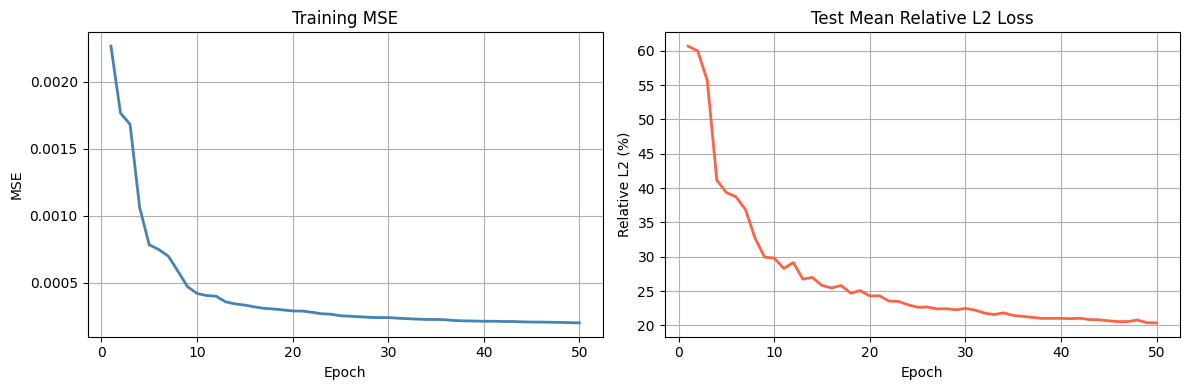

In [28]:
import os

epochs_range = range(1, epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, train_mse_history, color='steelblue', linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Training MSE")
axes[0].grid(True)

axes[1].plot(epochs_range, test_rel_l2_history, color='tomato', linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Relative L2 (%)")
axes[1].set_title("Test Mean Relative L2 Loss")
axes[1].grid(True)

plt.tight_layout()

plots_dir = "training_plots"
os.makedirs(plots_dir, exist_ok=True)
fig.savefig(os.path.join(plots_dir, "training_curves.png"), dpi=150, bbox_inches="tight")
print(f"Plot saved to {plots_dir}/training_curves.png")

plt.show()
